In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('./Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [28]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
# X= df.iloc[:, [3, 4]]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


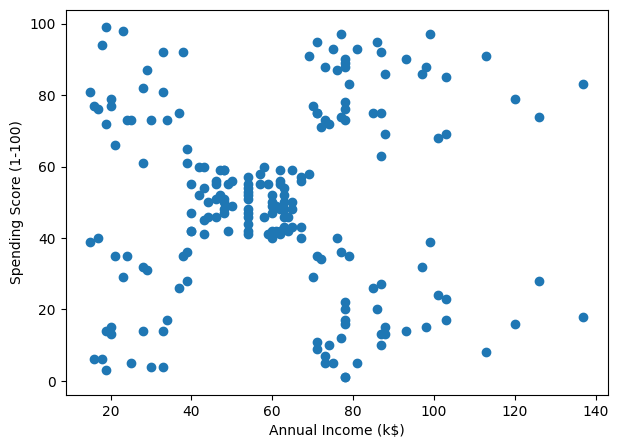

In [29]:
plt.figure(figsize=(7,5))
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_scaled= scalar.fit_transform(X)


In [40]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

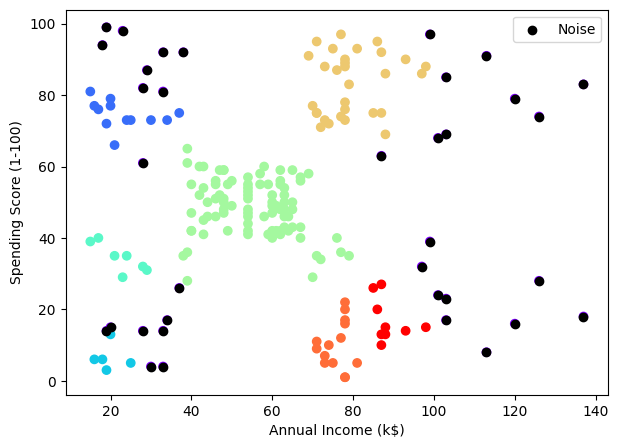

In [45]:
plt.figure(figsize=(7,5))
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'],c= clusters,cmap='rainbow')
plt.scatter(X.iloc[clusters==-1]['Annual Income (k$)'] , X.iloc[clusters==-1]['Spending Score (1-100)'],color='black', label='Noise')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [46]:

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)


Silhouette Score: 0.31614121976731185


In [47]:
eps_value = [0.2,0.3,0.5]

for eps in eps_value:
    print(f"Evaluating DBSCAN with eps={eps}")

    #Apply DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    #Number of clusters(Ignore label -1)

    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    print(f"Number of clusters: {n_clusters}")

    #Number of noise points
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    print(f"Number of noise points: {n_noise} (Noise Ratio: {noise_ratio:.2f})")


    #Shilhouette Score
    if n_clusters > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"Silhouette Score: {score:.4f}")
    else:
        print("Silhouette Score: Not applicable (only one cluster)")

Evaluating DBSCAN with eps=0.2
Number of clusters: 7
Number of noise points: 77 (Noise Ratio: 0.39)
Silhouette Score: 0.1406
Evaluating DBSCAN with eps=0.3
Number of clusters: 7
Number of noise points: 35 (Noise Ratio: 0.17)
Silhouette Score: 0.3161
Evaluating DBSCAN with eps=0.5
Number of clusters: 2
Number of noise points: 8 (Noise Ratio: 0.04)
Silhouette Score: 0.3504
